In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import pandas as pd
import harmonica as hm
from pyrocko import cake
import obspy

# NEWBERRY VOLCANO - Seismic Analysis
#### Rohan Batten

---
# 1. Initialialization

---
#### 1.1 - Basic Information

Newberry Volcano, Oregon

From given README file:
"The seismic data is collected as an active source (shot source) survey, with 50 geophones spaced 1000 m apart (for a total x distance of approximately 50,000 m). For the seismic analysis, the map (x,y) orientation of the survey does not matter, but that will be updated when you receive the gravity and magnetic data."

Mission

As a geophysicist employed by the Generic Geothermal Resource Company, you have been selected to perform a geophysical study of Newberry Volcano, a shield-shaped stratovolcano in the Cascade Range in Oregon. The current caldera formed about 75,000 years ago during a major explosive eruption, and the most recent eruption was approximately 1,300 years ago. Hot springs in the caldera are active.

While Newberry Volcano is quiet now, it has a very high capacity to cause damage– any eruption of a similar style to the previous eruptions could bury most of central Oregon. However, you are mostly interested in the area for the geothermal energy resources. Your job is NOT to recommend a specific site to drill for geothermal resources. Rather, your job is to (1) image the subsurface, (2) investigate general areas where magma might be more shallow (of interest due to the altered geothermal gradient), and (3) look for areas with hydrothermal activity due to easier access to geothermal resources. Make your judgement on the general areas where geothermal energy resources would be more accessible, explicitly state why you believe your ideas to be correct, and explain your reasoning.

For the upper layer of your seismic imaging: what are the most likely rock types for the upper layer? You don’t need to cite specific formations, but state a generic rock or deposit type (pyroclastic flow deposits, tuff, rhyolite, granite, basalt, glacial till, etc.). Combine your judgment on this (which should primarily be based on the measured velocities) with information from a geologic map. Again, you do not need to cite any specific formations or map units, just a generic rock type.

Geothermal energy resources are areas where Earth’s internal heat is available closer to the surface than average. These resources come in the form of hot springs (which are generally used directly for heating) and hot aquifers (which allow for actual generating of electricity).

---
#### 1.2 - Data Import and Assignment

In [2]:
# import data files for reflection (rl) and refraction (rc)
df_rl = pd.read_csv('newberry_reflections.csv', names=["x_rl", "p_rl_t1", "p_rl_t2", "p_rl_t3", "p_rl_t4"], skiprows=1)
df_rc = pd.read_csv('newberry_refractions.csv', names=["x_rc", "p_rc_t"], skiprows=1)  #skiprows so it doesn't include the header name

# assign each column of times to a variable
x_rl = df_rl['x_rl']
p_rl_t1 = df_rl['p_rl_t1']  # reflection
p_rl_t2 = df_rl['p_rl_t2']
p_rl_t3 = df_rl['p_rl_t3']
p_rl_t4 = df_rl['p_rl_t4']

x_rc = df_rc['x_rc']
p_rc_t = df_rc['p_rc_t']  # refraction

---
# 2. Plotting x/t Graphs

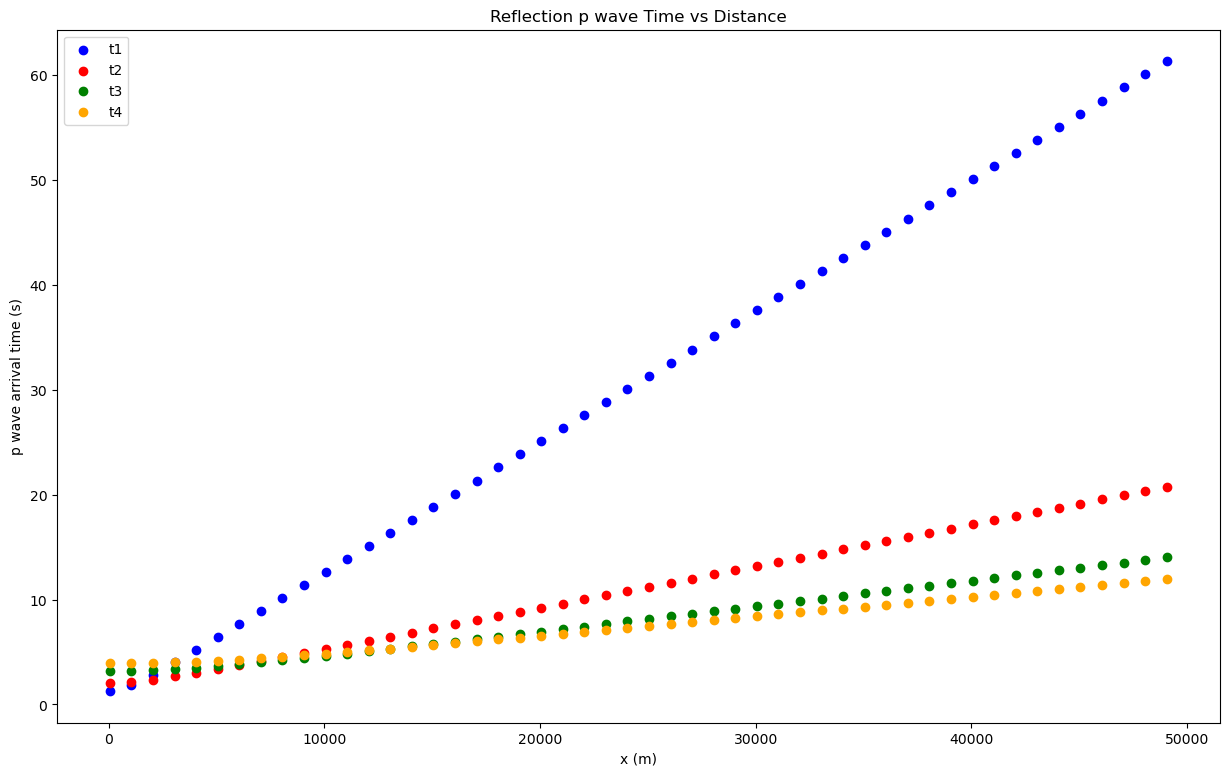

In [3]:
plt.figure(figsize=(15,9))

# reflections
plt.scatter(x_rl, p_rl_t1, color = 'blue', label = 't1')
plt.scatter(x_rl, p_rl_t2, color = 'red', label = 't2')
plt.scatter(x_rl, p_rl_t3, color = 'green', label = 't3')
plt.scatter(x_rl, p_rl_t4, color = 'orange', label = 't4')
plt.xlabel('x (m)')
plt.ylabel('p wave arrival time (s)')
plt.title('Reflection p wave Time vs Distance');
plt.legend()

plt.savefig('reflection_data_graphs.png', bbox_inches='tight')

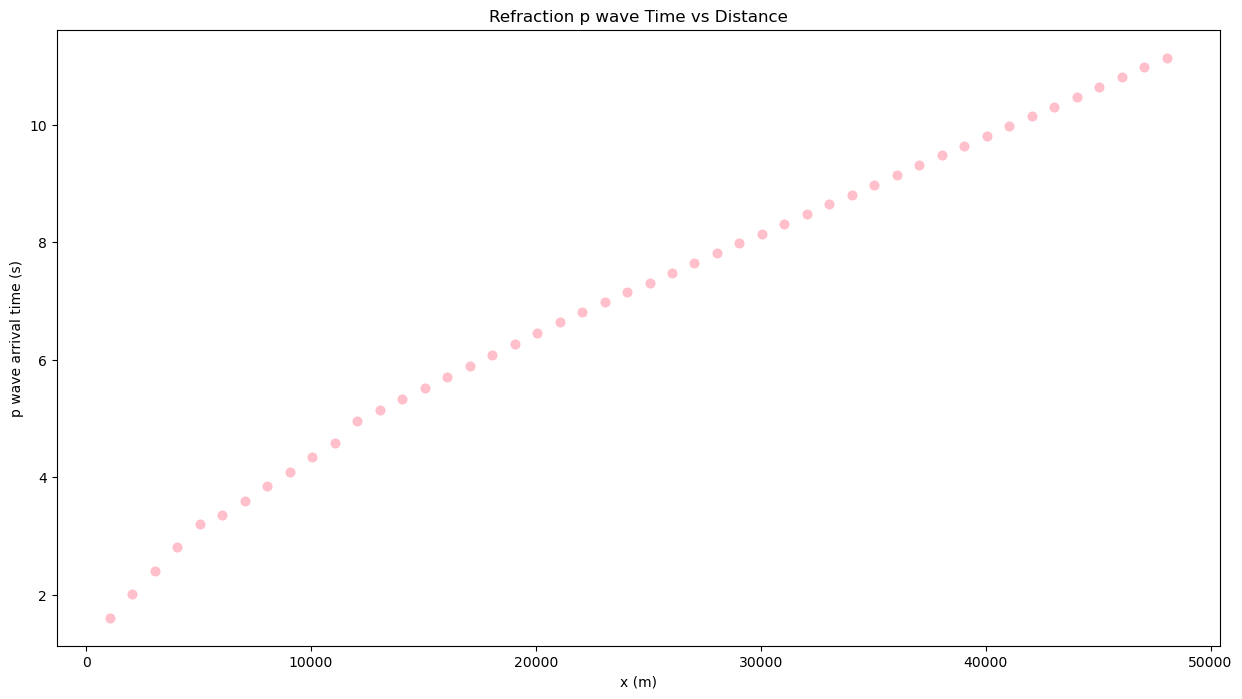

In [4]:
plt.figure(figsize=(15,8))

# refractions
plt.scatter(x_rc, p_rc_t, color = 'pink')
plt.xlabel('x (m)')
plt.ylabel('p wave arrival time (s)')
plt.title('Refraction p wave Time vs Distance');

plt.savefig('refraction_data_graph.png', bbox_inches='tight')

---
# 3 - Refraction


---
#### 3.1 - Refraction Analysis

Here, I split the data into two lists because it was duplicated. Ignore t_rc_rev, it is not needed, I just can't figure out sets.


In [5]:
# for loop to assign every even entry to a new list, so the doubled data is not included
# 96 values in refraction CSV means 48 values for forward and reverse each

i = 0;
t_rc_for = np.zeros((48,1))  # initialize arrays of zeros
t_rc_rev = np.zeros((48,1))
place_for = 0;  # place counter for each array
place_rev = 0;
x_rc_half = np.zeros(48)  # create new x array for 48 values
x_rc_half.reshape(-1,1)

while i < 96:  # starts at 0, go until 95 instead of 96
    if i % 2 == 0:
        t_rc_for[place_for] = p_rc_t[i]  # if even, assign the current t value to the current place we're in in the forward array
        x_rc_half[place_for] = x_rc[i]  # AND do the same for x, for an x array of just one set of positions
        place_for += 1

    else:
        t_rc_rev[place_rev] = p_rc_t[i]  # otherwise (if odd) assign to the reverse array
        place_rev += 1

    i += 1;  # increment count

print(np.array_equal(t_rc_for, t_rc_rev))  # check if the two are the same

# ---------------------------------------------------------------------------

# OR USE SET (i can't get it to work right now and it's not a priority)

#t_rc_organized = list(set(p_rc_t))

#print(np.array_equal(t_rc_for, t_rc_organized))

#p_rc_t

True


Now, we can use this single set of data to plot segments on the refraction graph. Through estimation, I found four segments. The breaks between segments are between indices 5 & 6, 11 & 12 and 21 & 22

This gives us four segments, creating four refractors, meaning four interfaces.

Segment 1 Slope: [0.00039837] s/m
Segment 1 Intercept: [1.19428096] s
 
Segment 2 Slope: [0.00024679] s/m
Segment 2 Intercept: [1.85877025] s
 
Segment 3 Slope: [0.00018853] s/m
Segment 3 Intercept: [2.67796573] s
 
Segment 4 Slope: [0.00016624] s/m
Segment 4 Intercept: [3.14852696] s
48
1


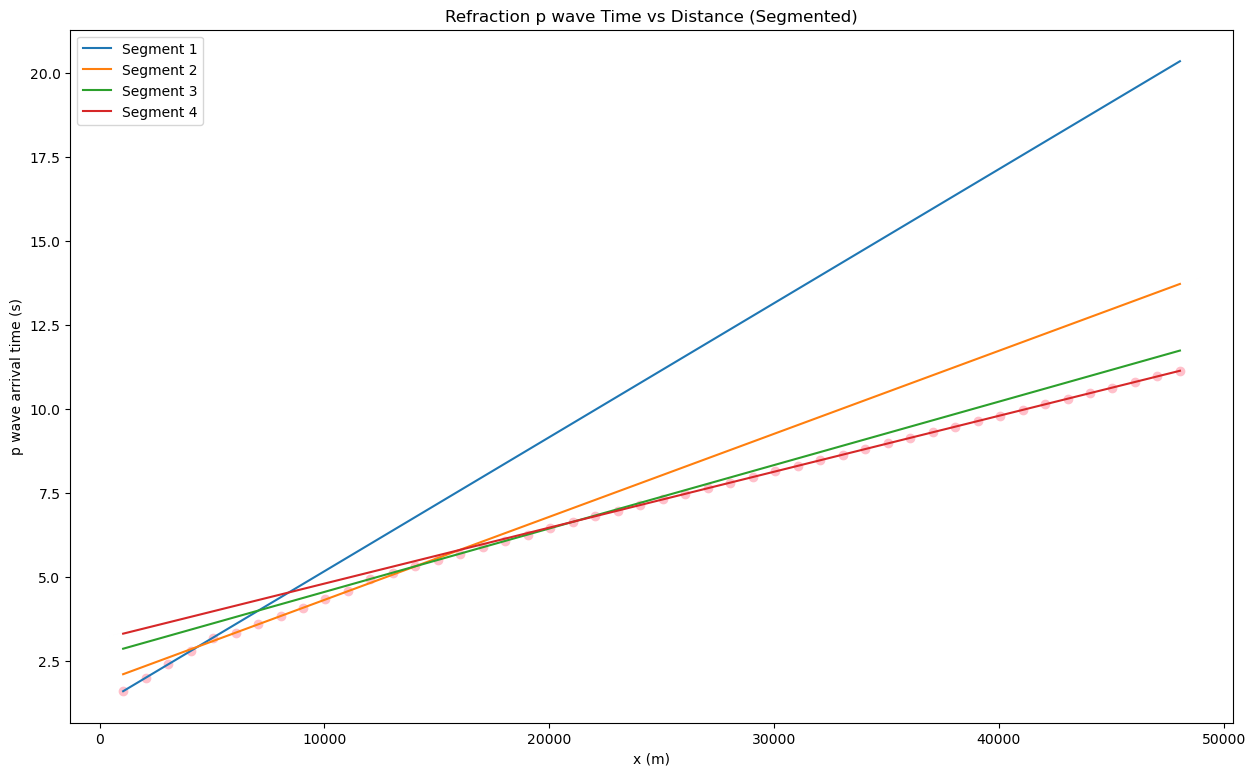

In [6]:
plt.figure(figsize=(15,9))


# Plot scatter plot with kinked segments
n_1 = 5  # the points at which the graph bends
n_2 = 11
n_3 = 21
n_4 = 48

#  plot the tangent lines using splits at n
seg1_slope, t_i_1 = np.polyfit(x_rc_half[:n_1], t_rc_for[:n_1], 1)
seg2_slope, t_i_2 = np.polyfit(x_rc_half[n_1:n_2], t_rc_for[n_1:n_2], 1)
seg3_slope, t_i_3 = np.polyfit(x_rc_half[n_2:n_3], t_rc_for[n_2:n_3], 1)
seg4_slope, t_i_4 = np.polyfit(x_rc_half[n_3:n_4], t_rc_for[n_3:n_4], 1)

y_seg1 = seg1_slope * x_rc_half + t_i_1  # y = mx + b for each segment to get y values
y_seg2 = seg2_slope * x_rc_half + t_i_2
y_seg3 = seg3_slope * x_rc_half + t_i_3
y_seg4 = seg4_slope * x_rc_half + t_i_4

plt.scatter(x_rc_half, t_rc_for, color = 'pink')
plt.plot(x_rc_half, y_seg1, label = 'Segment 1')  # plot the segments
plt.plot(x_rc_half, y_seg2, label = 'Segment 2')
plt.plot(x_rc_half, y_seg3, label = 'Segment 3')
plt.plot(x_rc_half, y_seg4, label = 'Segment 4')
plt.xlabel('x (m)')
plt.ylabel('p wave arrival time (s)')
plt.title('Refraction p wave Time vs Distance (Segmented)');
plt.legend();

print(f'Segment 1 Slope: {seg1_slope} s/m')
print(f'Segment 1 Intercept: {t_i_1} s')
print(' ')
print(f'Segment 2 Slope: {seg2_slope} s/m')
print(f'Segment 2 Intercept: {t_i_2} s')
print(' ')
print(f'Segment 3 Slope: {seg3_slope} s/m')
print(f'Segment 3 Intercept: {t_i_3} s')
print(' ')
print(f'Segment 4 Slope: {seg4_slope} s/m')
print(f'Segment 4 Intercept: {t_i_4} s')


print(np.size(t_rc_for))
test = len((np.transpose(t_rc_for)))
print(test)


plt.savefig('refraction_graphs.png', bbox_inches='tight')

The plot of $t$ vs $x$ for the refraction data shows three bends, leading to four segments. This would match the data, with four interfaces where layers 2, 3, 4 and then 5 are subsequently faster and therefore take over at a certain point.

---
#### 3.2 - Refraction Layer Velocities

To calculate the velocities for each layer, determining them from refraction is more reliable for shallower layers, which can then give us a better baseboard for the Dix equation later.

To do so, we use the arrival time equation and the segments we can see on the graph.

\begin{equation}
\tag{3.3.1}
t_{head,n} = \frac{x}{V_{n+1}} + \frac{2h\cos(θ_c)}{V_n},
\end{equation}

where $V_{n+1}$ is the velocity through the layer below the current one. Using this, we can see that the slope of a $t$ vs $x$ plot is going to be $\frac{1}{V_{n+1}}$, meaning that we just have to take the reciprocal of the slope for each segment between kinks on the above graph to find out layer velocities.

| Segment :      | 1        | 2        | 3        | 4        |
| ---------------| -------- | -------- | -------- | -------- |
| Points         |1-5       |6-11      |12-21     |22-48     |
| Start (m)      |1050      |6050      |13050     |24050     |
| End (m)        |5050      |12050     |23050     |48050     |
| Slope (s/m)    |0.00039837|0.00024679|0.00018853|0.00016624|
| Intercept (s)  |1.19428096|1.85877025|2.67796573|3.14852696|

We can't use this to find $V_1$, and have no direct wave arrival time to do it that way. We must derive it later with NMO and reflection waves.


In [7]:
# calculate V_n+1
V_2_rc = 1/seg1_slope
V_3_rc = 1/seg2_slope
V_4_rc = 1/seg3_slope
V_5_rc = 1/seg4_slope

print(f'Layer 2 Velocity: {V_2_rc} m/s')
print(f'Layer 3 Velocity: {V_3_rc} m/s')
print(f'Layer 4 Velocity: {V_4_rc} m/s')
print(f'Layer 5 Velocity: {V_5_rc} m/s')


Layer 2 Velocity: [2510.19857794] m/s
Layer 3 Velocity: [4051.95463568] m/s
Layer 4 Velocity: [5304.16451567] m/s
Layer 5 Velocity: [6015.38656103] m/s


---
# 4. Reflection

---
#### 4.1 - $t^2$ vs $x^2$

Travel time for a reflected wave is given by the equation

\begin{equation}
\tag{4.1.1}
t^2 = t_0^2 + \frac{x^2}{V_n^2},
\end{equation}

where $t_0$ is the up and down vertical travel time of a reflection and $V_n$ is the layer RMS velocity for layer $n$. Plotting $t^2$ vs $x^2$ will therefore show us the vertical travel time of each layer by taking the square root of the intercept, and the RMS velocity of the layer by taking the inverse of the square root of the slope.

Each layer will have it's own values and must be calculated separately to get the $V_{RMS}$. Then, we can use that to calculate the true $V_n$ through the Dix Equation.

This assumes flat layers.

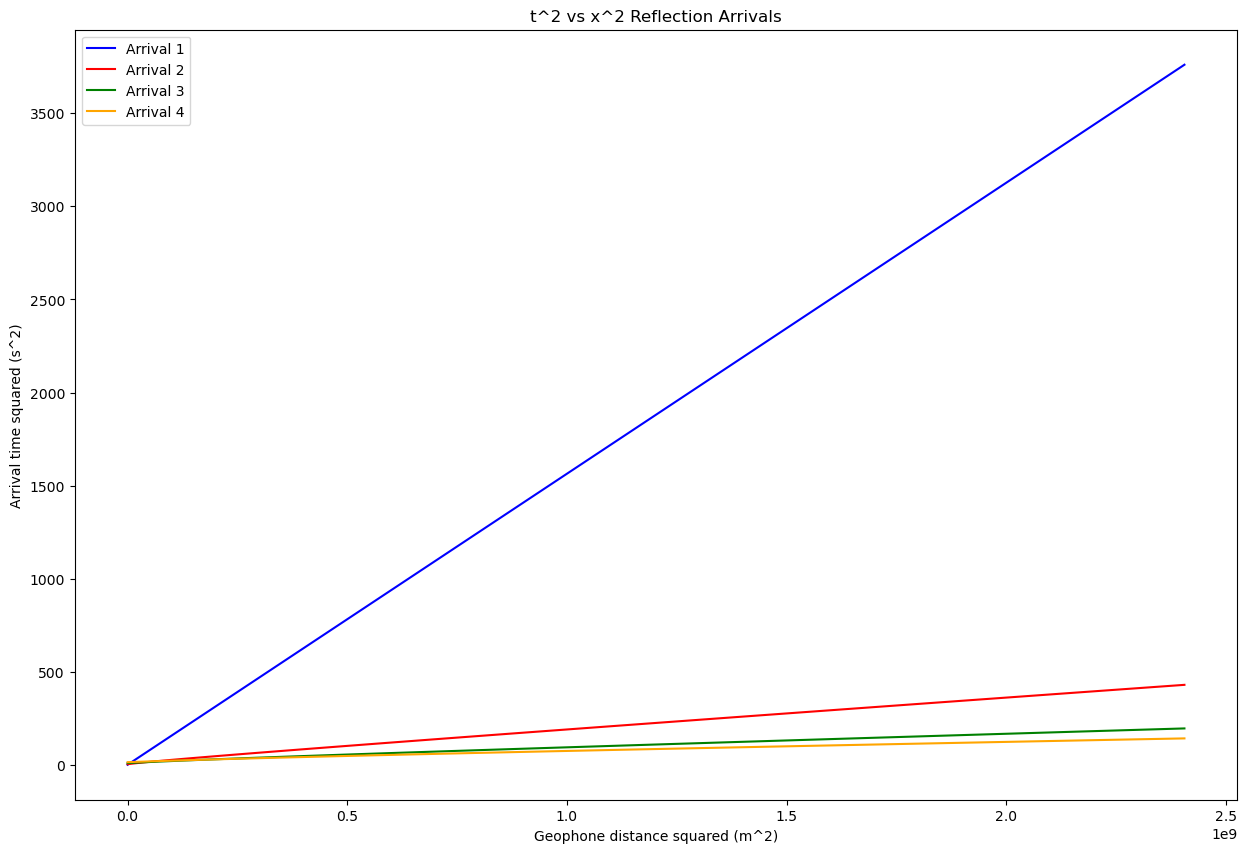

In [8]:
# plotting t^2 vs x^2
plt.figure(figsize=(15,10))
plt.ylabel('Arrival time squared (s^2)')
plt.xlabel('Geophone distance squared (m^2)')
plt.title('t^2 vs x^2 Reflection Arrivals')

plt.plot(x_rl**2, p_rl_t1**2, color = 'blue', label='Arrival 1')  # p wave 1

plt.plot(x_rl**2, p_rl_t2**2, color = 'red', label='Arrival 2')  # p wave 2

plt.plot(x_rl**2, p_rl_t3**2, color = 'green', label='Arrival 3')  # p wave 3

plt.plot(x_rl**2, p_rl_t4**2, color = 'orange', label='Arrival 4')  # p wave 4

plt.legend()

plt.savefig('reflection_tsqxsq_graphs.png', bbox_inches='tight')

In [9]:
# linear analysis to find slopes and intercepts
rl_slope1, rl_int1 = np.polyfit(x_rl**2, p_rl_t1**2, 1)  # p wave 1
rl_slope2, rl_int2 = np.polyfit(x_rl**2, p_rl_t2**2, 1)  # p wave 2
rl_slope3, rl_int3 = np.polyfit(x_rl**2, p_rl_t3**2, 1)  # p wave 3
rl_slope4, rl_int4 = np.polyfit(x_rl**2, p_rl_t4**2, 1)  # p wave 4

# then, use the inverse sqrt slope and sqrt intercept to find the V_RMS and t_0 for each layer
V_RMS_1 = 1 / np.sqrt(rl_slope1)
t_0_1 = np.sqrt(rl_int1)

V_RMS_2 = 1 / np.sqrt(rl_slope2)
t_0_2 = np.sqrt(rl_int2)

V_RMS_3 = 1 / np.sqrt(rl_slope3)
t_0_3 = np.sqrt(rl_int3)

V_RMS_4 = 1 / np.sqrt(rl_slope4)
t_0_4 = np.sqrt(rl_int4)

print('Arrival 1')
print(f'RMS velocity: {V_RMS_1} m/s')
print(f'Two way travel time: {t_0_1} m/s')
print(' ')
print('Arrival 2')
print(f'RMS velocity: {V_RMS_2} m/s')
print(f'Two way travel time: {t_0_2} m/s')
print(' ')
print('Arrival 3')
print(f'RMS velocity: {V_RMS_3} m/s')
print(f'Two way travel time: {t_0_3} m/s')
print(' ')
print('Arrival 4')
print(f'RMS velocity: {V_RMS_4} m/s')
print(f'Two way travel time: {t_0_4} m/s')

Arrival 1
RMS velocity: 800.0320760205128 m/s
Two way travel time: 1.2601484544411379 m/s
 
Arrival 2
RMS velocity: 2379.7544132003195 m/s
Two way travel time: 3.3338750822816987 m/s
 
Arrival 3
RMS velocity: 3593.972458249189 m/s
Two way travel time: 3.855201144105031 m/s
 
Arrival 4
RMS velocity: 4330.674474439786 m/s
Two way travel time: 4.40819091111611 m/s


---
#### 4.2 - Dix Equation

From the RMS velocities, we can then also the Dix equation,

\begin{equation}
\tag{4.2.1}
V_n = \sqrt{\frac{V_{RMS,n}^2 * t_{0,n} - V_{RMS,n-1}^2 * t_{0,n-1}}{t_{0,n} - t_{0,n-1}}}
\end{equation}

to acquire the interval velocities of each layer. Then we can use

\begin{equation}
\tag{4.2.2}
t_{0,n} = \frac{2h}{V_n}
\end{equation}

to get the depths of each interface.

In [10]:
# Dix calculations
V_1_rl = V_RMS_1  # top layer just takes the RMS velocity
V_2_rl = np.sqrt(((V_RMS_2**2 * t_0_2) - (V_RMS_1**2 * t_0_1)) / (t_0_2 - t_0_1))
V_3_rl = np.sqrt(((V_RMS_3**2 * t_0_3) - (V_RMS_2**2 * t_0_2)) / (t_0_3 - t_0_2))
V_4_rl = np.sqrt(((V_RMS_4**2 * t_0_4) - (V_RMS_3**2 * t_0_3)) / (t_0_4 - t_0_3))
# No data for layer 5 (we only get layers above interface 4 with reflection)

# Interface depth calculations
h_1 = (V_1_rl * t_0_1) / 2  # interface depths
h_2 = (V_2_rl * t_0_2) / 2
h_3 = (V_3_rl * t_0_3) / 2
h_4 = (V_4_rl * t_0_4) / 2

print(f'Layer 1 Velocity: {V_1_rl} m/s')
print(f'Layer 2 Velocity: {V_2_rl} m/s')
print(f'Layer 3 Velocity: {V_3_rl} m/s')
print(f'Layer 4 Velocity: {V_4_rl} m/s')
print(' ')
print(f'Interface 1 Depth: {h_1} m')
print(f'Interface 2 Depth: {h_2} m')
print(f'Interface 3 Depth: {h_3} m')
print(f'Interface 4 Depth: {h_4} m')

Layer 1 Velocity: 800.0320760205128 m/s
Layer 2 Velocity: 2952.233670499331 m/s
Layer 3 Velocity: 7700.785988422634 m/s
Layer 4 Velocity: 7710.734548976956 m/s
 
Interface 1 Depth: 504.0795920502921 m
Interface 2 Depth: 4921.189135575379 m
Interface 3 Depth: 14844.039476537466 m
Interface 4 Depth: 16995.194978414598 m


---
# 5 - Finishing Layers

To calculate the true layer velocity, we need to decide which analysis is more trustworthy.

| Layer :                     | 1                | 2                 | 3               | 4               | 5           |
| ----------------------------| ---------------- | ----------------- | --------------- | --------------- | ----------- |
| V_RMS (m/s)                 |800.0320760205128 |2379.7544132003195 |3593.972458249189|4330.674474439786| -           |
| V_n_rl (m/s)                |800.0320760205128 |2952.233670499331  |7700.785988422634|7710.734548976956| -           |
| V_n_rc (m/s)                | -                |2510.19857794      |4051.95463568    |5884.78656288    |6015.38656103|
| t_0 (rl) (s)                |1.2601484544411379|3.3338750822816987 |3.855201144105031|4.40819091111611 | -           |
| t_0 (rc) (s)                |1.2601484544411379|1.19428096         |1.85877025       |2.67796573       | 3.14852696  |

Reflection analysis gave an answer that doesn't make sense, and I don't know what's wrong with it. Layers 3 and 4 having a difference of only 10 m/s is suspicious, and the interface depths calculated from them were far too deep.

I made a choice to go with the refraction analysis. The Dix equation seems to be unstable at the deeper layers, whereas refraction (although a more complicated and "eyeballed" process) seems to be more in line with what I would expect from this subsurface.

$V_1$ matches for both analyses though, and we can take it as true for layer 1.


In [11]:
# final velocity values
V_1 = V_RMS_1  # 800.0320760205128 m/s
V_2 = V_2_rc   # 2510.19857794 m/s
V_3 = V_3_rc   # 4051.95463568 m/s
V_4 = V_4_rc   # 5884.78656288 m/s
V_5 = V_5_rc   # 6015.38656103 m/s

---
#### 5.1 - Layer Thickness and Interface Depth

We can use the intercept time equation for interfaces 2, 3, and 4, solved for thickness $h$:

\begin{equation}
\tag{5.1.1}
h_n = (t_{i,n} - \bigg[\frac{2h_{s}\sqrt{V_{n+1}^2 - V_{s}^2}}{V_{n+1}V_{s}}\bigg]) * (\frac{V_{n+1}V_n}{2\sqrt{V_{n+1}^2 - V_n^2}})
\end{equation}

where the bracketed section is repeated for every layer $s$ above the current one (so interface 3 would remove contributions from layers 1 and 2, but not 3).

We will instead just use the basic velocity formula for interface 1, as there is only one layer above it.

\begin{equation}
\tag{5.1.2}
h_1 = \frac{t_{0,1}V_{1}}{2}
\end{equation}

It is divided by two because of the two-way travel time.

In [12]:
# calculate h
h_1 = (t_0_1 * V_RMS_1) / 2
h_1 = h_1.item()  # converting from np float to float for function usage later

layer2_delay = t_i_2 - (2 * h_1 * np.sqrt(V_3**2 - V_1**2)) / (V_3 * V_1)  # calculate time delay (first section in eq. 5.1.1)
h_2 = layer2_delay * ((V_3 * V_2) / (2 * np.sqrt(V_3**2 - V_2**2)))
h_2 = h_2.item()

layer3_delay = t_i_3 - ((2 * h_1 * np.sqrt(V_4**2 - V_1**2)) / (V_4 * V_1)) - ((2 * h_2 * np.sqrt(V_4**2 - V_2**2)) / (V_4 * V_2))
h_3 = layer3_delay * ((V_4 * V_3) / (2 * np.sqrt(V_4**2 - V_3**2)))
h_3 = h_3.item()

layer4_delay = t_i_4 - ((2 * h_1 * np.sqrt(V_5**2 - V_1**2)) / (V_5 * V_1)) - ((2 * h_2 * np.sqrt(V_5**2 - V_2**2)) / (V_5 * V_2)) - ((2 * h_3 * np.sqrt(V_5**2 - V_3**2)) / (V_5 * V_3))
h_4 = layer4_delay * ((V_4 * V_3) / (2 * np.sqrt(V_4**2 - V_3**2)))
h_4 = h_4.item()

print(f'Layer 1 Thickness: {h_1} m')
print(f'Layer 2 Thickness: {h_2} m')
print(f'Layer 3 Thickness: {h_3} m')
print(f'Layer 4 Thickness: {h_4} m')

Layer 1 Thickness: 504.0795920502921 m
Layer 2 Thickness: 996.7780397656902 m
Layer 3 Thickness: 2300.0734193175863 m
Layer 4 Thickness: 1063.5258036230928 m


From these, we can easily get the interface depths.

In [13]:
z_1 = h_1
z_2 = z_1 + h_2  # calculate depths of each interface by adding the thickness of the next layer
z_3 = z_2 + h_3
z_4 = z_3 + h_4

print(f'Interface 1 Depth: {z_1} m')
print(f'Interface 2 Depth: {z_2} m')
print(f'Interface 3 Depth: {z_3} m')
print(f'Interface 4 Depth: {z_4} m')

Interface 1 Depth: 504.0795920502921 m
Interface 2 Depth: 1500.8576318159824 m
Interface 3 Depth: 3800.931051133569 m
Interface 4 Depth: 4864.456854756661 m


---
# 6 - Seismic Conclusion

So, our overall seismic data gives us the following

| Layer :      | 1     | 2      | 3      | 4      | 5      |
| -------------| ----- | ------ | ------ | ------ | ------ |
| V (m/s)      |800.03 |2510.20 |4051.95 |5884.79 |6015.39 |
| h (m)        |504.08 |996.78  |2300.07 |1063.53 |-       |
| Ceiling (m)  |0      |504.08  |1500.86 |3800.93 |4864.46 |
| Floor (m)    |504.08 |1500.86 |3800.93 |4864.46 |-       |

---
#### 6.1 - Rock Interpretation

See report for sources of rock densities and more reasoning.

#### - Layer 1 -
Layer 1 is likely a layer of looser volcanic material. Sediments from lahars, the lakes of the caldera, or loose pumice stones would all be reasonable. Additionally, the slowness of the layer would also indicate it is not a dense material.

Layer 1: Loose pumice deposits (Qyrp / Qyp on geologic map) [~700 kg/m^3]


#### - Layer 2 -
Layer 2 is a faster layer, and a bit thicker. This faster wave speed is consistent with a denser layer, such as tuff that has been lunched into the air and subsequently buried under further layers.

Layer 2: Lightly compressed tuff (Qat?) [~1500 kg/m^3]


#### - Layer 3 -
Layer 3 begins to get faster. ~4000 m/s is almost fast enough for basalt/igneous rocks, but not quite. This makes me think it is more tuff, simply a layer that is deeper, older, and more compressed. This transitions nicely from previous layers into rocks like basalt. I believe Qat from earlier was eroded away, revealing Qpt in the caldera.

Layer 3: More compressed tuff (Qpt) [~2400 kg/m^3]


#### - Layer 4 -
Layer 4 is where the igneous basalt begins. This layer is fast, fast enough to be indicative of a dense magma rock.

Layer 4: Basaltic andesite (Qba) [~2700 kg/m^3]


#### - Layer 5 -
Layer 5 is just a little faster, but still in line for basalt. It would be an older basalt layer, and perhaps a little more compressed.

Layer 5: Basalt (Tb?) [~2900 kg/m^3]


---
#### 6.2 - Cross Section


Folllowing code is the layer model function provided by Emily Wilbur.

In [14]:
def seismic_cross_section(interfaces,velocities,filename):
    ########## FUNCTION DETAILS: PLEASE READ #################################################################################
    # interfaces = array of interface depths as positive values, [meters]                                                    #
    # velocities = list of strings of layer P wave velocities, [m/s]                                                         #
    # filename   = filename to save the plot as a string, ex: 'my-seismic-cross-section.png'                                 #
    # ^^^^^^^^^^^^^^^^^^^^^ PLEASE READ AND RESPECT THE TYPES OF INPUTS (OR YOU WILL HAVE TERRIBLE ERRORS) ^^^^^^^^^^^^^^^^^ #
    ##########################################################################################################################
    
    # check the lengths of velocities (list) and interface depths (array) please:
    if len(velocities)==len(interfaces)+1:
        print('Making the plot now...')
    else:
        print("I can't plot this! Fix length of array and/or list to match: len(interface depths) = n, len(velocities) = n+1.")
        return None

    # Define the parameters
    distance   = np.linspace(0,50000,1000)    # x distance across the volcano [m]
    surface    = np.zeros_like(distance)      # surface vector
    basement   = surface - 10000              # lower bound for the plot
    receiver_x = np.linspace(0,50000,100)     # receiver spacing
    receiver_y = 100*np.ones_like(receiver_x) # you need a y vector to plot the x vector

    interfaces = np.abs(interfaces)           # in case you forget to make the interface depths POSITIVE, I fix it for you

    layers       = np.zeros([len(interfaces)+2,len(distance)]) # initializing layers for plotting by # of input interfaces
    layers[0,:]  = surface                                     # first layer starts at the surface
    layers[-1,:] = basement                                    # last layer ends with lower bound of plot
    for i in range(len(interfaces)):
        layers[i+1,:] = surface - interfaces[i]                # fill middle with the input interfaces (from YOU, dear reader)

    # colors for plotting the layers
    c_list = plt.cm.viridis_r(np.linspace(0,1,len(interfaces)+2))
    
    # now actually make the figure (don't worry about it):
    plt.figure(figsize=(15,6),dpi=300)
    for i in range(len(interfaces)+1):
        plt.fill_between(distance,layers[i,:],layers[i+1,:],where=layers[i,:]>layers[i+1,:],color=c_list[i],label=velocities[i])
    for i in range(1,len(interfaces)+1):
        plt.plot(distance,layers[i],color='black',linestyle='--')
    plt.plot(distance,surface,color='black')
    plt.plot(25000*np.ones(250), np.linspace(1000,-10001,250),linestyle=':',linewidth=3,color='white',alpha=0.8) # x coord of peak
    plt.scatter(25000,270,marker='^',s=280,color='brown')         # tiny 'volcano' peak 
    plt.scatter(receiver_x,receiver_y,marker='^', color='black')  # receivers
    plt.ylim(-10000,1000)
    plt.xlim(0,50000)
    plt.xlabel('Distance [m]',fontsize=14)
    plt.ylabel('Depth [m]',fontsize=14)
    plt.legend(fontsize=12)
    plt.savefig(filename, bbox_inches='tight')
    plt.show();

In [15]:
# define array of interface depths:
int_default = np.array([z_1, z_2, z_3, z_4]) # interface depths in meters

# define list of velocities (include units):
vel_default = ['v1 = 800.03   [m/s]','v2 = 2510.20 [m/s]','v3 = 4052.00 [m/s]','v4 = 5884.79 [m/s]', 'v5 = 6015.39 [m/s]']

##############################################################################################
#  NB: velocity list should be of length n+1, for n = length of array of interface depths,   #
#  and the plotting function will accommodate any length of interface array as long as the   #
#  length of the velocity list follows the rule above. :)                                    #
##############################################################################################

# check that you are following the rule above:
print('length of array of interface depths = ', len(int_default), " = n")
print('length of list of velocities        = ', len(vel_default), " = n+1")

length of array of interface depths =  4  = n
length of list of velocities        =  5  = n+1


Making the plot now...


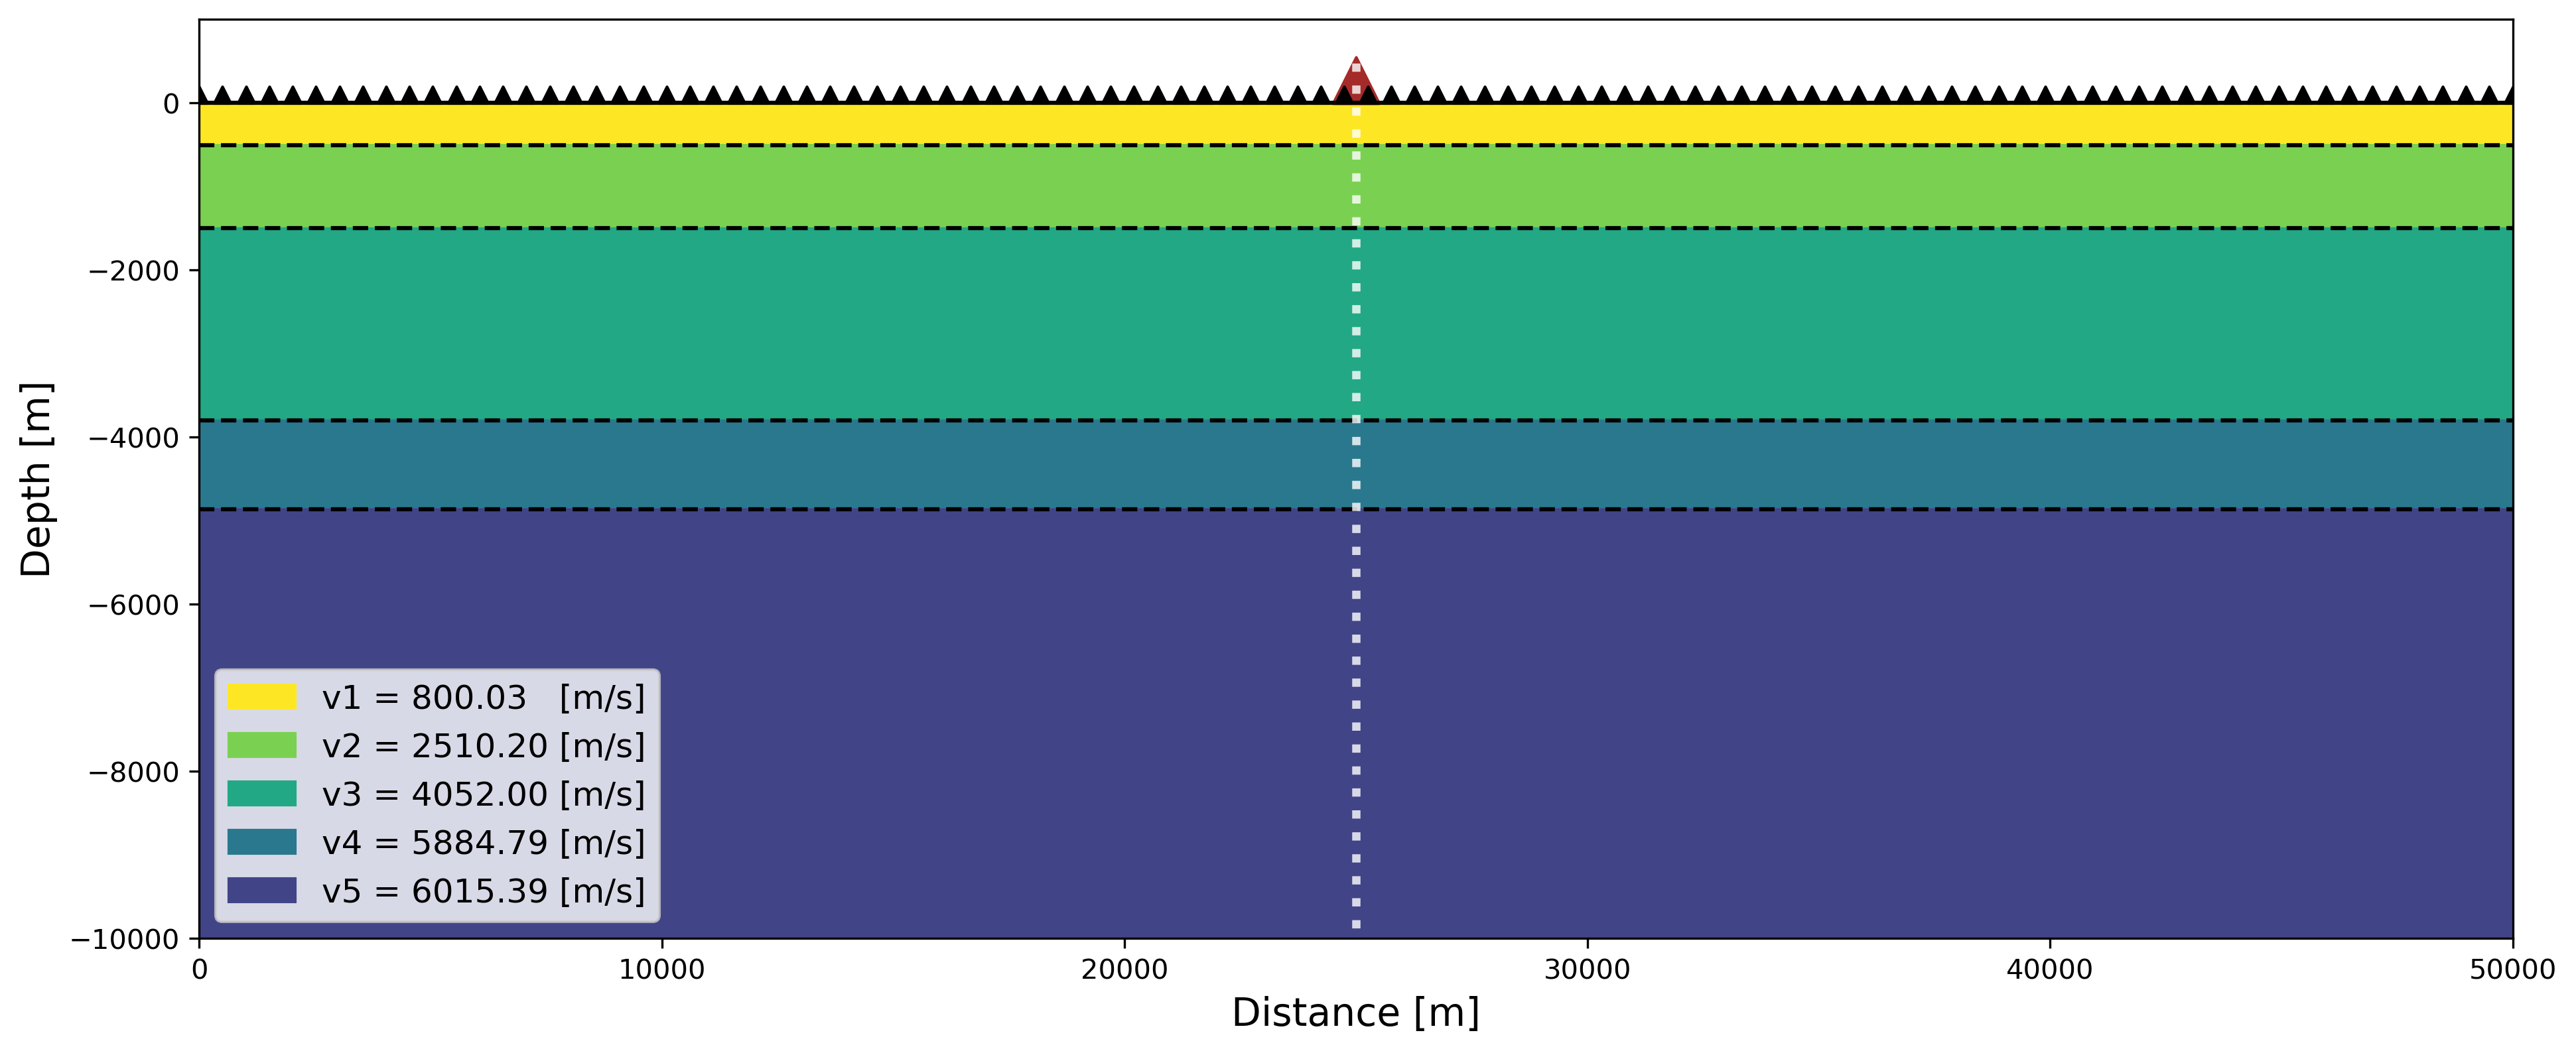

In [16]:
# actually make the plot:
final_plot = seismic_cross_section(int_default,vel_default,'newberry-final-seismic-plot.png')